In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
rootutils.setup_root('.', dotenv=True, pythonpath=True, cwd=False)

PosixPath('/home/milton/workspace/ocdm')

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import csv
from pathlib import Path

import wandb
import polars as pl
import plotly.io as pio
import plotly.express as px
import numpy as np
import torch
import torch.nn as nn
from torchvision.utils import make_grid

from src.model.autoencoder import BetaVAE, WassersteinMMDAE
from src.model.grouping import SlotAutoencoder, FigureGroundAutoencoder
from src.model.regression import Regressor
from src.dataset.dsprites import DSprites
from src.dataset.shapes3d import Shapes3D
from src.dataset.pentominos import Pentominos
from src.dataset.datamodule import DisentangledDataModule
from src.dataset.utils import build_filter
from src.analysis.viz import strip

api = wandb.Api()

torch.set_grad_enabled(False)

wandb: Currently logged in as: mlle to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


torch.autograd.grad_mode.set_grad_enabled(mode=False)

# Latent size analysis

## Difference in score

In [ ]:


# Example: get all runs in a project
runs = api.runs("mlle/ocdm")

dfs = {}

def extract_config_values(cfg):
    return {
        'dataset': cfg['dataset']['_target_'].split('.')[-1],
        'held_out_filter': cfg['dataset']['held_out_filter'],
        'model': cfg['model']['_target_'].split('.')[-1],
        'representation_size': cfg['model']['latent_size' if 'latent_size' in cfg['model'] else 'slot_size'],
    }

for run in runs:
    # Fetch full history (W&B stores as pages; this handles it)
    history = run.history(samples=10_000_000)  # big number = no pagination cutoff
    df = pl.from_pandas(history)
    df = df.with_columns(pl.col('epoch').cast(pl.Int64, strict=True))
    df = df.with_columns(pl.lit(run.id).alias("run_id"))
    
    cfg = extract_config_values(run.config)

    # one config row per run
    config_df = pl.DataFrame([cfg | {"run_id": run.id}])
    config_df = config_df.with_columns(pl.col("held_out_filter").fill_null("None"))

    merged = df.join(config_df, on='run_id', how='left')

    dfs[run.id] = merged

run_table = pl.concat(dfs.values(), how='diagonal')

In [ ]:
run_table

In [ ]:
shapes_3d_combgen = run_table\
    .filter(pl.col('dataset') == "Shapes3D")\
    .filter(pl.col('held_out_filter') == "( shape == 3 ) & ( posX < 0.5 )")\
    .filter(pl.col('model') != "SLATE")\
    .filter(pl.col('model') != "FigureGroundSLATE")\
    # .filter(pl.col('model') != "BetaVAE")

In [ ]:
import plotly.io as pio
import plotly.express as px

pio.renderers.default = "notebook"

val_scores = shapes_3d_combgen.filter(
    pl.col('val/loss').is_not_nan()).group_by(['run_id', 'model', 'representation_size']).agg(
    pl.col('val/loss').gather(pl.col("epoch").arg_max())
).with_columns(pl.col("val/loss").list.first())



fig = px.box(
    val_scores.to_pandas(),
    x='representation_size',
    y='val/loss',
    color='model',
    # barmode='group',
)
# fig.update_xaxes(tickmode="array", tickvals=val_scores["representation_size"].to_list())
fig.show()

## Classifier scoring

In [3]:
def load_npz_to_rows(path: Path, model_name: str):
    data = np.load(path)

    rows = []
    for key, value in data.items():
        split, metric = key.rsplit("_", 1)
        rows.append({
            "model": model_name,
            "metric": metric,
            "split": split,
            "value": np.nanmean(value),
        })

    return rows

def load_json_to_rows(path, model_name, metric):
    rows = []
    with open(path, newline='') as csvfile:
        reader = csv.reader(csvfile, delimiter=',')
        for i, data in enumerate(reader):
            if i == 0:
                # print(data)
                continue
            split, value, std, min_, max_ = data
            rows.append({
                "model": model_name,
                "metric": metric,
                "split": split,
                "value": float(value),
            }) 
    return rows

def load_vlm_to_rows(path, model_name):
    rows = []
    with open(path, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            rows.append({
                "model": model_name,
                "metric": "accuracy",
                "split": row["split"],
                "value": float(row["accuracy"]),
            })
    return rows

_KEY_ALIASES = {
    'factor_prediction_scores': 'prediction_scores',
    'latent_prediction_scores': 'prediction_scores',
}

def load_metrics(models, scores):
    result = {}
    for model_name, score_files in zip(models, scores):
        for path in score_files:
            path = Path(path)
            key = _KEY_ALIASES.get(path.stem, path.stem)
            rows = result.setdefault(key, [])
            if path.suffix == '.npz':
                rows.extend(r for r in load_npz_to_rows(path, model_name) if r['split'] == 'test')
            elif key == 'vlm_eval':
                rows.extend(load_vlm_to_rows(path, model_name))
            else:
                rows.extend(load_json_to_rows(path, model_name, 'perceptual'))
    return result

## dSprites shape and position

In [4]:
vae_scores = [
    # "../data/results/figure1/combgen_dsprites_heart_position_vae_on:2025-11-12_13-45/latent_prediction_scores.npz",
    # "../data/results/figure1/combgen_dsprites_heart_position_vae_on:2025-11-12_13-45/discriminator_scores.npz",
    "../data/results/figure1/combgen_dsprites_heart_position_vae_on:2025-11-12_13-45/clip_similarities.csv",
    "../data/results/figure1/combgen_dsprites_heart_position_vae_on:2025-11-12_13-45/vlm_eval.csv",
]

wae_scores = [
    # "../data/results/figure1/combgen_dsprites_heart_position_wae_on:2025-11-20_09-21/latent_prediction_scores.npz",
    # "../data/results/figure1/combgen_dsprites_heart_position_wae_on:2025-11-20_09-21/discriminator_scores.npz",
    "../data/results/figure1/combgen_dsprites_heart_position_wae_on:2025-11-20_09-21/clip_similarities.csv",
    "../data/results/figure1/combgen_dsprites_heart_position_wae_on:2025-11-20_09-21/vlm_eval.csv",
]

sa_scores = [
    # "../data/results/figure1/combgen_dsprites_heart_position_sa_on:2026-03-13_13-12/latent_prediction_scores.npz",
    # "../data/results/figure1/combgen_dsprites_heart_position_sa_on:2026-03-13_13-12/discriminator_scores.npz",
    "../data/results/figure1/combgen_dsprites_heart_position_sa_on:2026-03-13_13-12/clip_similarities.csv",
    "../data/results/figure1/combgen_dsprites_heart_position_sa_on:2026-03-13_13-12/vlm_eval.csv",
]

dsprirtes_shape_position = load_metrics(['vae', 'wae', 'sa1'], [vae_scores, wae_scores, sa_scores])

## 3D Shapes object hue

In [5]:
vae_scores = [
    # "../data/results/figure1/combgen_shapes3d_shape_hue_vae_on:2025-11-19_14-21/latent_prediction_scores.npz",
    # "../data/results/figure1/combgen_shapes3d_shape_hue_vae_on:2025-11-19_14-21/discriminator_scores.npz",
    "../data/results/figure1/combgen_shapes3d_shape_hue_vae_on:2025-11-19_14-21/clip_similarities.csv",
    "../data/results/figure1/combgen_shapes3d_shape_hue_vae_on:2025-11-19_14-21/vlm_eval.csv",
]

wae_scores = [
    # "../data/results/figure1/combgen_shapes3d_shape_hue_wae_on:2025-11-19_16-58/factor_prediction_scores.npz",
    # "../data/results/figure1/combgen_shapes3d_shape_hue_wae_on:2025-11-19_16-58/discriminator_scores.npz",
    "../data/results/figure1/combgen_shapes3d_shape_hue_wae_on:2025-11-19_16-58/clip_similarities.csv",
    "../data/results/figure1/combgen_shapes3d_shape_hue_wae_on:2025-11-19_16-58/vlm_eval.csv",
]

sa_scores = [
    # "../data/results/figure1/combgen_shapes3d_shape_hue_sa_on:2025-11-19_18-02/factor_prediction_scores.npz",
    # "../data/results/figure1/combgen_shapes3d_shape_hue_sa_on:2025-11-19_18-02/discriminator_scores.npz",
    "../data/results/figure1/combgen_shapes3d_shape_hue_sa_on:2025-11-19_18-02/clip_similarities.csv",
    "../data/results/figure1/combgen_shapes3d_shape_hue_sa_on:2025-11-19_18-02/vlm_eval.csv",
]

shapes3d_object_hue = load_metrics(['vae', 'wae', 'sa1'], [vae_scores, wae_scores, sa_scores])

## dSprites shape rotation

In [6]:
vae_scores = [
    # "../data/results/figure1/combgen_dsprites_heart_rotation_vae_on:2025-11-27_00-02/latent_prediction_scores.npz",
    # "../data/results/figure1/combgen_dsprites_heart_rotation_vae_on:2025-11-27_00-02/discriminator_scores.npz",
    "../data/results/figure1/combgen_dsprites_heart_rotation_vae_on:2025-11-27_00-02/clip_similarities.csv",
    "../data/results/figure1/combgen_dsprites_heart_rotation_vae_on:2025-11-27_00-02/vlm_eval.csv",
]

wae_scores = [
    # "../data/results/figure1/combgen_dsprites_heart_rotation_wae_on:2025-11-27_02-12/latent_prediction_scores.npz",
    # "../data/results/figure1/combgen_dsprites_heart_rotation_wae_on:2025-11-27_02-12/discriminator_scores.npz",
    "../data/results/figure1/combgen_dsprites_heart_rotation_wae_on:2025-11-27_02-12/clip_similarities.csv",
    "../data/results/figure1/combgen_dsprites_heart_rotation_wae_on:2025-11-27_02-12/vlm_eval.csv",
]

sa_scores = [
    # "../data/results/figure1/combgen_dsprites_heart_rotation_sa_on:2026-03-03_05-57/latent_prediction_scores.npz",
    # "../data/results/figure1/combgen_dsprites_heart_rotation_sa_on:2026-03-03_05-57/discriminator_scores.npz",
    "../data/results/figure1/combgen_dsprites_heart_rotation_sa_on:2026-03-03_05-57/clip_similarities.csv",
    "../data/results/figure1/combgen_dsprites_heart_rotation_sa_on:2026-03-03_05-57/vlm_eval.csv",
]

dsprites_shape_rotation = load_metrics(['vae', 'wae', 'sa1'], [vae_scores, wae_scores, sa_scores])

In [30]:
len(dsprirtes_shape_position)

3

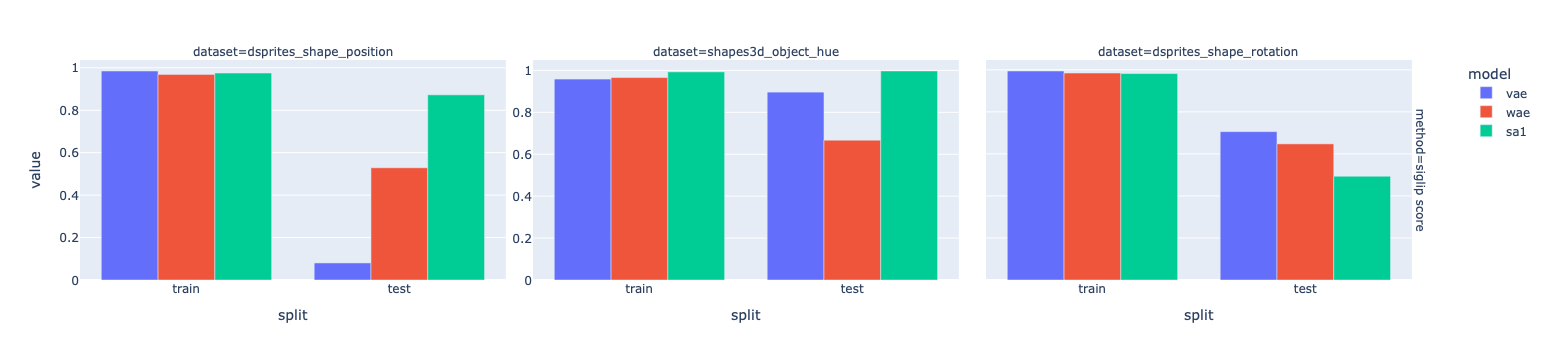

In [9]:
dfs = []
for dataset, scores in zip(['dsprites_shape_position', 'shapes3d_object_hue', 'dsprites_shape_rotation'], [dsprirtes_shape_position, shapes3d_object_hue, dsprites_shape_rotation]):
    dfs.extend([
        # pl.DataFrame(scores['prediction_scores']).with_columns(pl.lit("factor_classificaton").alias('method')).with_columns(pl.lit(dataset).alias('dataset')),
        # pl.DataFrame(scores['discriminator_scores']).with_columns(pl.lit("discriminator").alias('method')).with_columns(pl.lit(dataset).alias('dataset')),
        # pl.DataFrame(scores['clip_similarities']).with_columns(pl.lit("perceptual sim").alias('method')).with_columns(pl.lit(dataset).alias('dataset')),
        pl.DataFrame(scores['vlm_eval']).with_columns(pl.lit("siglip score").alias('method')).with_columns(pl.lit(dataset).alias('dataset')),
    ])

df = pl.concat(dfs)

fig = px.bar(
    # df.filter(pl.col('metric') == 'acc').to_pandas(),
    df.to_pandas(),
    x='split',
    y='value',
    color='model',
    facet_col="dataset",
    facet_row='method',
    barmode='group',
)
fig.update_yaxes(matches=None)
fig.update_yaxes(showticklabels=True, col=2) # assuming second facet
fig.write_image('../plots/figure1-scores.pdf', width=1200, height=300)
fig

## Pentominos shape and rotation

In [10]:
vae_scores = [
    # "../data/results/figure2/combgen_pentominos_w_rotation_vae_on:2025-12-11_14-09/latent_prediction_scores.npz",
    # "../data/results/figure2/combgen_pentominos_w_rotation_vae_on:2025-12-11_14-09/discriminator_scores.npz",
    "../data/results/figure2/combgen_pentominos_w_rotation_vae_on:2025-12-11_14-09/clip_similarities.csv",
    "../data/results/figure2/combgen_pentominos_w_rotation_vae_on:2025-12-11_14-09/vlm_eval.csv",
]

wae_scores = [
    # "../data/results/figure2/combgen_pentominos_w_rotation_wae_on:2025-12-11_16-16/latent_prediction_scores.npz",
    # "../data/results/figure2/combgen_pentominos_w_rotation_wae_on:2025-12-11_16-16/discriminator_scores.npz",
    "../data/results/figure2/combgen_pentominos_w_rotation_wae_on:2025-12-11_16-16/clip_similarities.csv",
    "../data/results/figure2/combgen_pentominos_w_rotation_wae_on:2025-12-11_16-16/vlm_eval.csv",
]

sa_scores = [
    # "../data/results/figure2/combgen_pentominos_rotation_sa_on:2026-03-07_22-58/latent_prediction_scores.npz",
    # "../data/results/figure2/combgen_pentominos_rotation_sa_on:2026-03-07_22-58/discriminator_scores.npz",
    "../data/results/figure2/combgen_pentominos_rotation_sa_on:2026-03-07_22-58/clip_similarities.csv",
    "../data/results/figure2/combgen_pentominos_rotation_sa_on:2026-03-07_22-58/vlm_eval.csv",
]

pentominos_shape_rotation = load_metrics(['vae', 'wae', 'sa1'], [vae_scores, wae_scores, sa_scores])

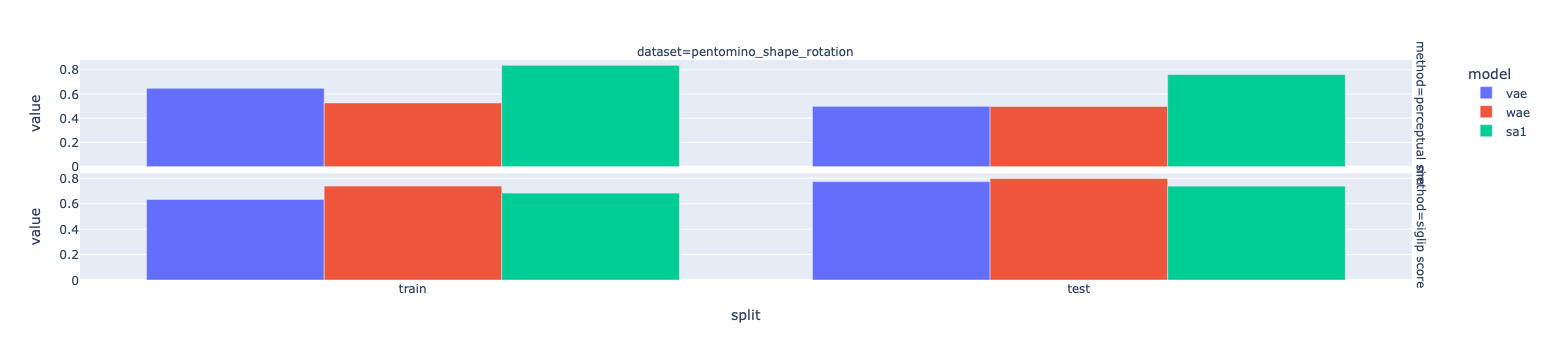

In [11]:
dfs = []
for dataset, scores in zip(['pentomino_shape_rotation'], [pentominos_shape_rotation]):
    dfs.extend([
       pl.DataFrame(scores['clip_similarities']).with_columns(pl.lit("perceptual sim").alias('method')).with_columns(pl.lit(dataset).alias('dataset')),
       pl.DataFrame(scores['vlm_eval']).with_columns(pl.lit("siglip score").alias('method')).with_columns(pl.lit(dataset).alias('dataset')),
    ])

df = pl.concat(dfs)

fig = px.bar(
    df.to_pandas(),
    x='split',
    y='value',
    color='model',
    facet_col="dataset",
    facet_row='method',
    barmode='group',
)
fig.update_yaxes(matches=None)
fig.update_yaxes(showticklabels=True, col=2) # assuming second facet
fig